# 05 - Financial Analysis Visualizations

Figure 2 uses Smart automobile expansion (2010–2021), Transition Year (2022), and AI expansion (2023–2026), including source-review years 2025–2026. Other figures retain their stated historical windows through 2024. All figures describe entities in this dataset.

In [1]:
from pathlib import Path
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.patches import Patch

## Load and validate

In [2]:
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "data" / "processed").is_dir() else cwd.parent
input_path = project_root / "data" / "processed" / "financials_features.csv"
figures_dir = project_root / "figures"
if not input_path.is_file():
    raise FileNotFoundError(f"Feature dataset not found: {input_path}")
if not figures_dir.is_dir():
    raise FileNotFoundError(f"Figures directory not found: {figures_dir}")

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as file_handle:
        for chunk in iter(lambda: file_handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

csv_paths = sorted((project_root / "data").rglob("*.csv"))
csv_hashes_before = {str(path.relative_to(project_root)): file_sha256(path) for path in csv_paths}
df = pd.read_csv(input_path)
df_main = df.loc[df.year.le(2024)].copy()
expected_groups = {"Foundry", "Fabless", "IDM", "Equipment", "EDA Software"}
input_validation = {
    "row_count_617": len(df) == 617,
    "unique_year_company": not df.duplicated(["year", "company_name"]).any(),
    "no_infinite_values": not df.select_dtypes(include="number").isin([float("inf"), float("-inf")]).any().any(),
    "five_value_chain_groups": set(df.value_chain_group.dropna()) == expected_groups,
    "main_subset_maximum_year_2024": int(df_main.year.max()) == 2024,
}
for check, passed in input_validation.items():
    assert passed, f"Input validation failed: {check}"
display(pd.Series(input_validation, name="passed").to_frame())

,passed
row_count_617,True
unique_year_company,True
no_infinite_values,True
five_value_chain_groups,True
main_subset_maximum_year_2024,True


## Visual system and reusable helpers

In [3]:
GROUP_ORDER = ["Foundry", "Fabless", "IDM", "Equipment", "EDA Software"]
GROUP_COLORS = {
    "Foundry": "#174A7E",
    "Fabless": "#F28E2B",
    "IDM": "#2E7D32",
    "Equipment": "#7B4AB5",
    "EDA Software": "#C43C39",
}
SOURCE_NOTE = "Source: Global Semiconductor Industry dataset; author calculations."
LIMITATION_NOTE = "Shares and rankings refer only to entities represented in the dataset."
figure_records = []

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
})

def add_chart_title(fig, title, subtitle):
    fig.suptitle(title, x=0.06, y=0.985, ha="left", fontsize=16, fontweight="bold")
    fig.text(0.06, 0.945, subtitle, ha="left", va="top", fontsize=10, color="#555555")

def format_axis(ax, xlabel=None, ylabel=None, horizontal_grid=True):
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if horizontal_grid:
        ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.7)
        ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color("#AAAAAA")
    ax.spines["bottom"].set_color("#AAAAAA")

def add_footer(fig, extra_note=None):
    footer = SOURCE_NOTE + "  " + LIMITATION_NOTE
    if extra_note:
        footer += "  " + extra_note
    fig.text(0.06, 0.012, footer, ha="left", va="bottom", fontsize=7.5, color="#666666")

def save_figure(fig, filename, maximum_year_used, extra_note=None):
    add_footer(fig, extra_note)
    fig.tight_layout(rect=[0.04, 0.07, 0.98, 0.91])
    output = figures_dir / filename
    fig.savefig(output, dpi=300, bbox_inches="tight", facecolor="white")
    figure_records.append({"figure_filename": filename, "maximum_year_used": maximum_year_used, "source_note_included": True, "limitation_note_included": True})
    return output

## Figure 1 — Industry revenue trend and coverage

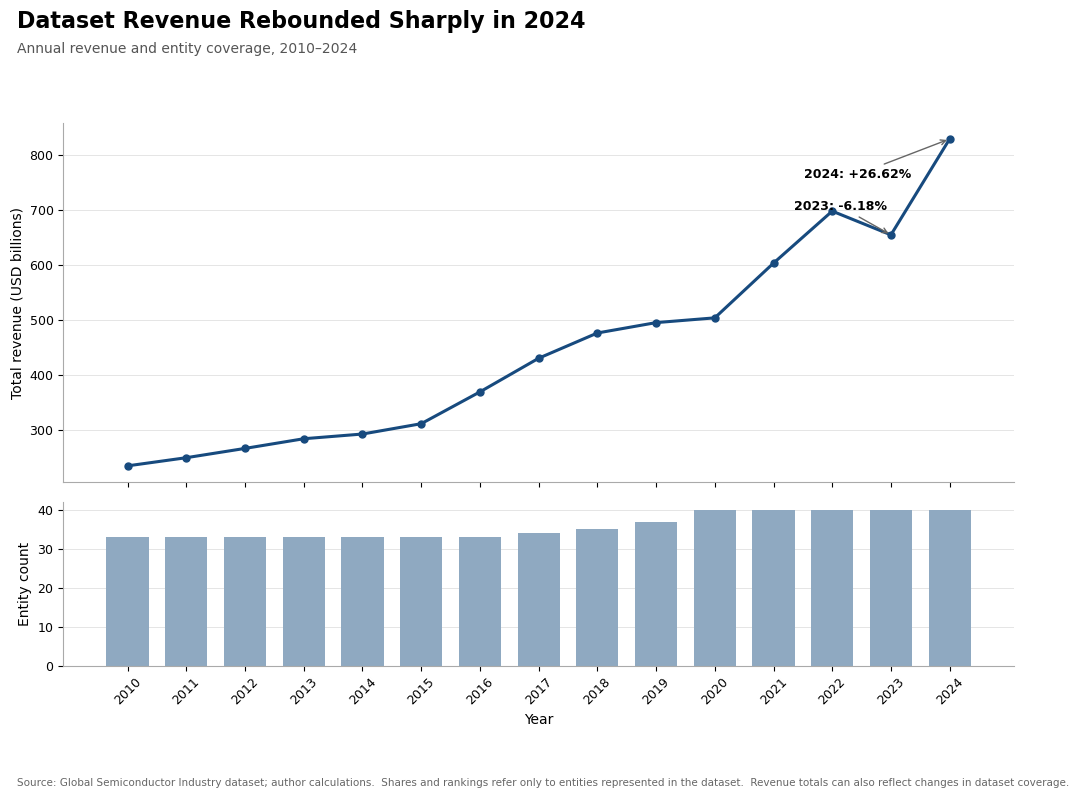

In [4]:
trend = df_main.groupby("year").agg(total_revenue_usd_bn=("revenue_usd_bn", "sum"), company_count=("company_name", "nunique")).reset_index()
trend["growth_pct"] = trend.total_revenue_usd_bn.pct_change(fill_method=None).mul(100)
assert round(float(trend.loc[trend.year.eq(2023), "growth_pct"].iloc[0]), 2) == -6.18, "Figure 1 validation failed: 2023 growth differs from approved EDA."
assert round(float(trend.loc[trend.year.eq(2024), "growth_pct"].iloc[0]), 2) == 26.62, "Figure 1 validation failed: 2024 growth differs from approved EDA."
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
add_chart_title(fig, "Dataset Revenue Rebounded Sharply in 2024", "Annual revenue and entity coverage, 2010–2024")
ax_top.plot(trend.year, trend.total_revenue_usd_bn, color="#174A7E", marker="o", linewidth=2.2, markersize=5)
for year, label, offset in [(2023, "2023: -6.18%", (-70, 18)), (2024, "2024: +26.62%", (-105, -28))]:
    row = trend.loc[trend.year.eq(year)].iloc[0]
    ax_top.annotate(label, (row.year, row.total_revenue_usd_bn), xytext=offset, textcoords="offset points", arrowprops={"arrowstyle": "->", "color": "#666666"}, fontsize=9, fontweight="bold")
format_axis(ax_top, ylabel="Total revenue (USD billions)")
ax_bottom.bar(trend.year, trend.company_count, color="#8FA9C1", width=0.72)
format_axis(ax_bottom, xlabel="Year", ylabel="Entity count")
ax_bottom.set_xticks(trend.year)
ax_bottom.tick_params(axis="x", rotation=45)
path_1 = save_figure(fig, "01_industry_revenue_trend.png", int(trend.year.max()), "Revenue totals can also reflect changes in dataset coverage.")
plt.show()

## Figure 2 — Value-chain revenue across the three analysis periods

,Smart automobile expansion,Transition Year,AI expansion
value_chain_group,,,
Foundry,52.639167,119.96,139.5125
Fabless,65.396667,154.83,322.0425
IDM,209.585833,317.07,322.9825
Equipment,44.427500,97.26,114.6125
EDA Software,4.415000,8.34,11.2575


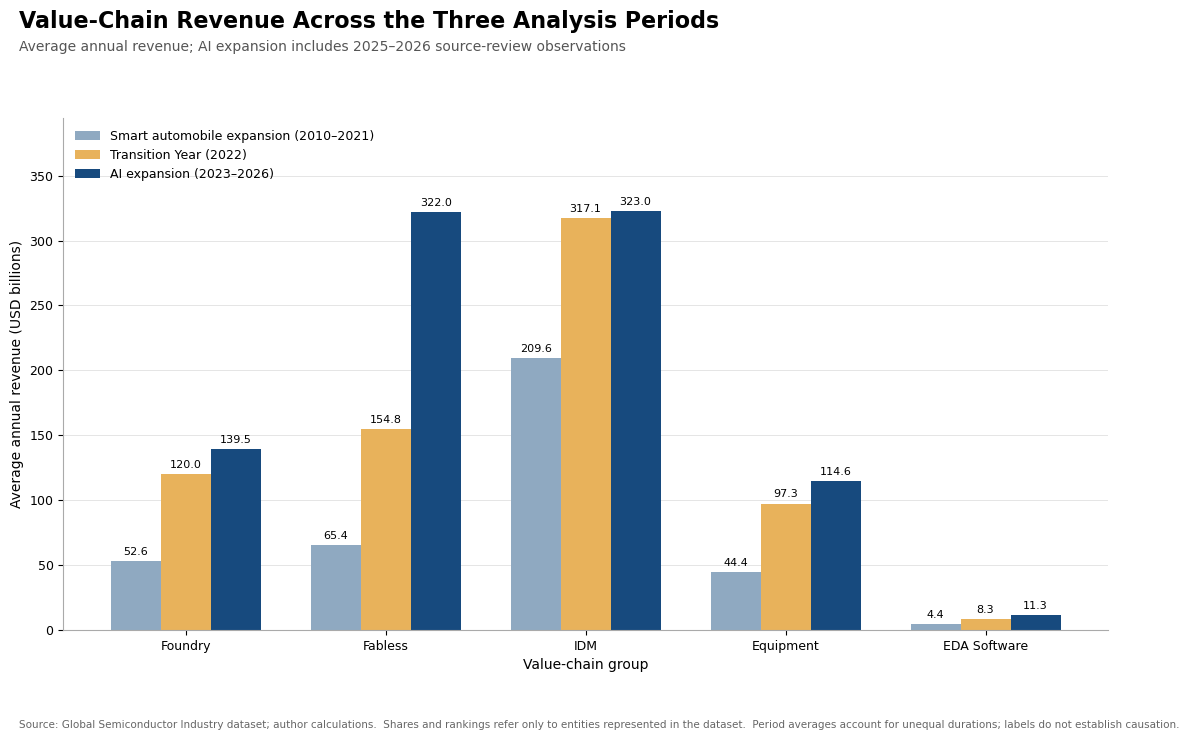

In [5]:
period_order = ["Smart automobile expansion", "Transition Year", "AI expansion"]
period_values = {}
for label in period_order:
    frame = df.loc[df.analysis_period.eq(label)]
    period_values[label] = frame.groupby(["year", "value_chain_group"]).revenue_usd_bn.sum().groupby("value_chain_group").mean().reindex(GROUP_ORDER)
period_table = pd.DataFrame(period_values)
assert period_table.notna().all().all(), "Missing group-period revenue."
display(period_table)
fig, ax = plt.subplots(figsize=(12, 7.4))
add_chart_title(fig, "Value-Chain Revenue Across the Three Analysis Periods", "Average annual revenue; AI expansion includes 2025–2026 source-review observations")
x = list(range(len(GROUP_ORDER)))
width = 0.25
colors = ["#8FA9C1", "#E8B25B", "#174A7E"]
labels = ["Smart automobile expansion (2010–2021)", "Transition Year (2022)", "AI expansion (2023–2026)"]
for index, period in enumerate(period_order):
    bars = ax.bar([value + (index - 1) * width for value in x], period_table[period], width, color=colors[index], label=labels[index])
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_xticks(x, GROUP_ORDER)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.margins(y=0.22)
format_axis(ax, xlabel="Value-chain group", ylabel="Average annual revenue (USD billions)")
path_2 = save_figure(fig, "02_value_chain_pre_vs_ai.png", 2026, "Period averages account for unequal durations; labels do not establish causation.")
plt.show()

## Figure 3 — Top entities by 2024 revenue

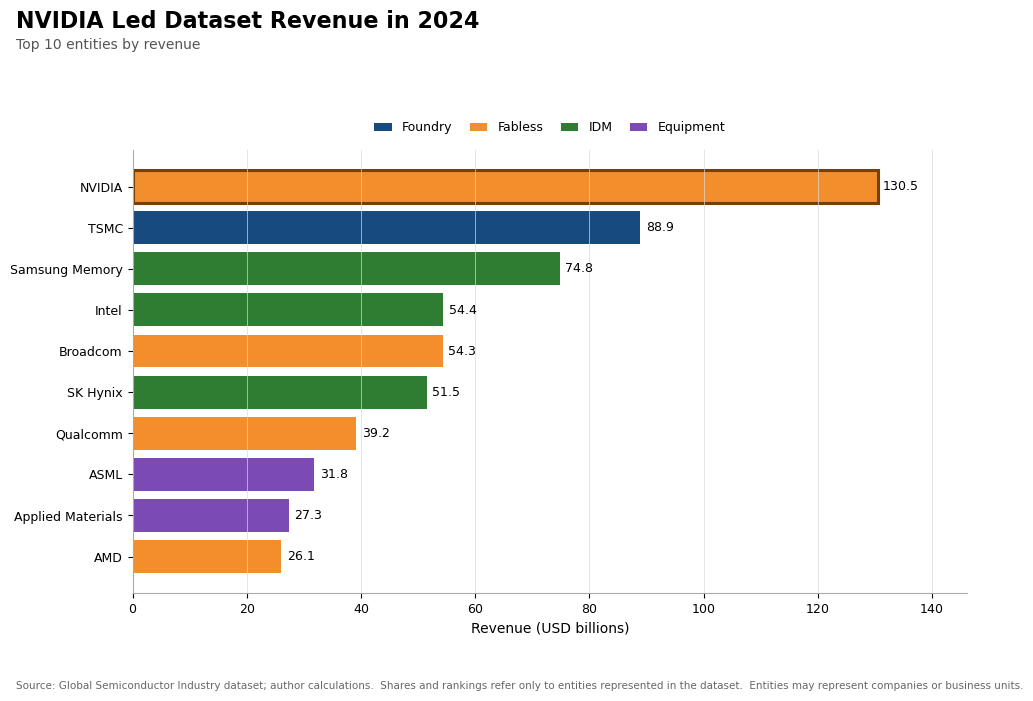

In [6]:
top_2024 = df_main.loc[df_main.year.eq(2024)].nlargest(10, "revenue_usd_bn").sort_values("revenue_usd_bn")
assert top_2024.iloc[-1].company_name == "NVIDIA", "Figure 3 validation failed: NVIDIA is not first by 2024 revenue."
fig, ax = plt.subplots(figsize=(10.5, 7))
add_chart_title(fig, "NVIDIA Led Dataset Revenue in 2024", "Top 10 entities by revenue")
bars = ax.barh(top_2024.company_name, top_2024.revenue_usd_bn, color=[GROUP_COLORS[group] for group in top_2024.value_chain_group])
for bar, company in zip(bars, top_2024.company_name):
    if company == "NVIDIA":
        bar.set_edgecolor("#7A3E00")
        bar.set_linewidth(2.2)
ax.bar_label(bars, labels=[f"{value:.1f}" for value in top_2024.revenue_usd_bn], padding=4, fontsize=9)
present_top10_groups = [group for group in GROUP_ORDER if group in set(top_2024.value_chain_group)]
top10_legend = [Patch(facecolor=GROUP_COLORS[group], label=group) for group in present_top10_groups]
ax.legend(handles=top10_legend, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=len(top10_legend), frameon=False, handlelength=1.4, columnspacing=1.4)
ax.margins(x=0.12)
format_axis(ax, xlabel="Revenue (USD billions)", ylabel=None, horizontal_grid=False)
ax.grid(axis="x", color="#D9D9D9", linewidth=0.7, alpha=0.7)
path_3 = save_figure(fig, "03_top10_revenue_2024.png", 2024, "Entities may represent companies or business units.")
plt.show()

## Figure 4 — Absolute revenue change, 2022–2024

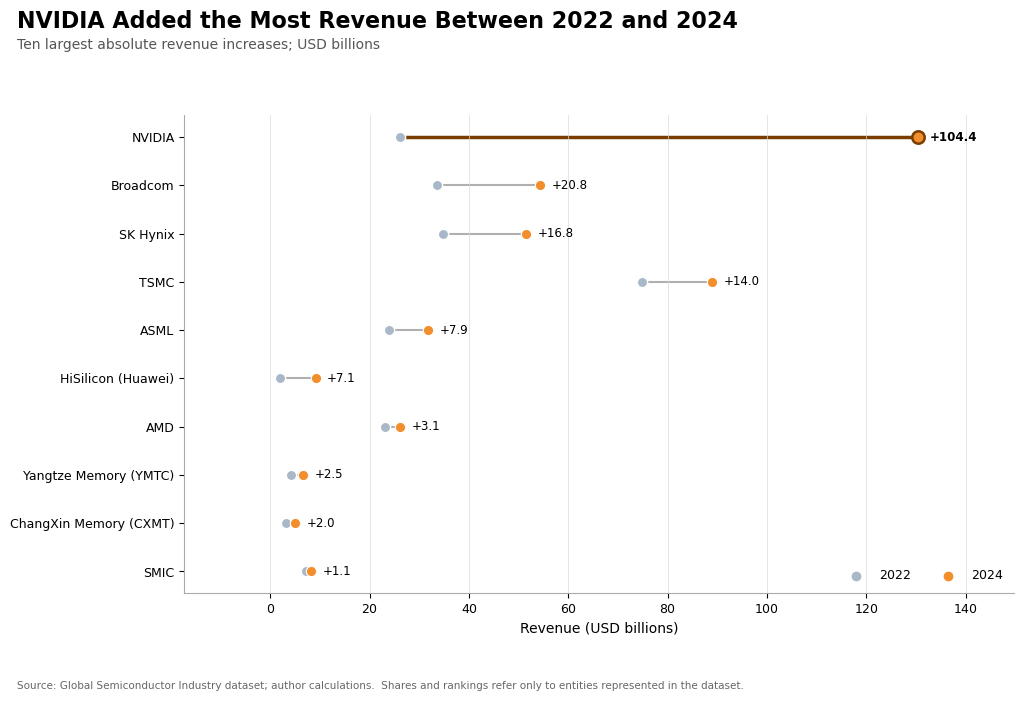

In [7]:
revenue_endpoints = df_main.loc[df_main.year.isin([2022, 2024])].pivot(index="company_name", columns="year", values="revenue_usd_bn").dropna().rename(columns={2022: "revenue_2022", 2024: "revenue_2024"})
revenue_endpoints["absolute_change"] = revenue_endpoints.revenue_2024 - revenue_endpoints.revenue_2022
top_change = revenue_endpoints.nlargest(10, "absolute_change").sort_values("absolute_change")
assert top_change.iloc[-1].name == "NVIDIA", "Figure 4 validation failed: NVIDIA is not the largest absolute gainer."
fig, ax = plt.subplots(figsize=(11, 7))
add_chart_title(fig, "NVIDIA Added the Most Revenue Between 2022 and 2024", "Ten largest absolute revenue increases; USD billions")
y_positions = list(range(len(top_change)))
for y, (company, row) in zip(y_positions, top_change.iterrows()):
    emphasis = company == "NVIDIA"
    ax.plot([row.revenue_2022, row.revenue_2024], [y, y], color="#B0B0B0" if not emphasis else "#7A3E00", linewidth=2.5 if emphasis else 1.5, zorder=1)
    ax.scatter(row.revenue_2022, y, color="#A8B8C8", s=55, zorder=2, edgecolor="white")
    ax.scatter(row.revenue_2024, y, color="#F28E2B", s=80 if emphasis else 55, zorder=2, edgecolor="#7A3E00" if emphasis else "white", linewidth=1.8 if emphasis else 0.8)
    ax.text(row.revenue_2024 + top_change.revenue_2024.max() * 0.018, y, f"+{row.absolute_change:.1f}", va="center", fontsize=8.5, fontweight="bold" if emphasis else "normal")
ax.set_yticks(y_positions, top_change.index)
ax.scatter([], [], color="#A8B8C8", label="2022")
ax.scatter([], [], color="#F28E2B", label="2024")
ax.legend(frameon=False, ncol=2, loc="lower right")
ax.margins(x=0.15)
format_axis(ax, xlabel="Revenue (USD billions)", ylabel=None, horizontal_grid=False)
ax.grid(axis="x", color="#D9D9D9", linewidth=0.7, alpha=0.7)
path_4 = save_figure(fig, "04_revenue_change_2022_2024.png", 2024)
plt.show()

## Figure 5 — Revenue concentration

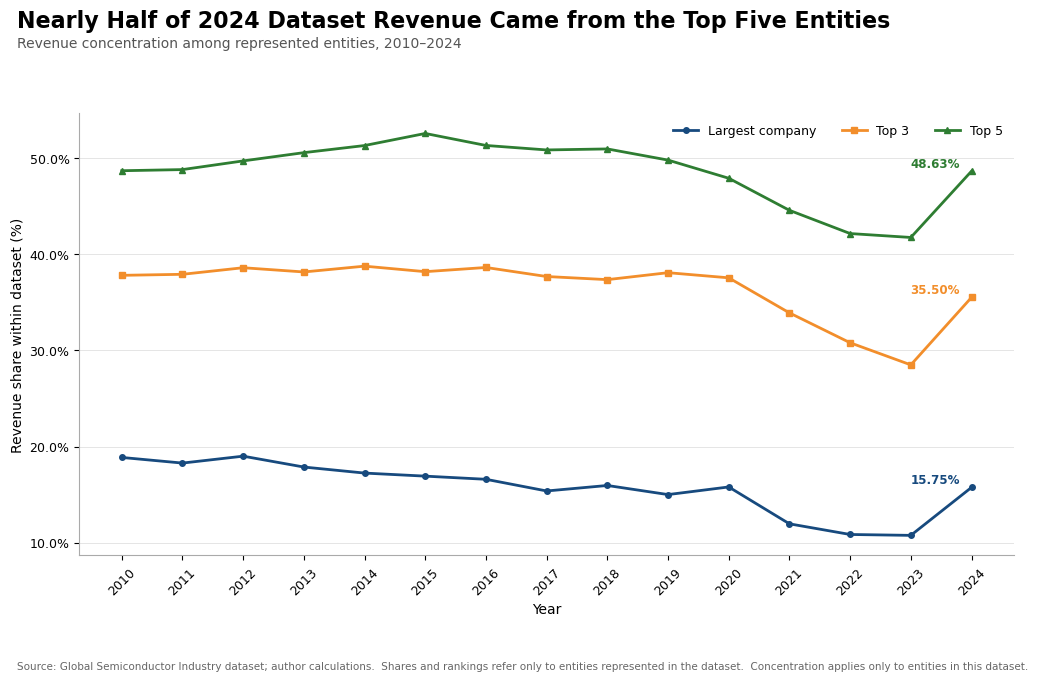

In [8]:
concentration_records = []
for year, group in df_main.groupby("year"):
    shares = group.revenue_usd_bn.div(group.revenue_usd_bn.sum()).mul(100).sort_values(ascending=False)
    concentration_records.append({"year": year, "Largest company": shares.iloc[0], "Top 3": shares.head(3).sum(), "Top 5": shares.head(5).sum()})
concentration = pd.DataFrame(concentration_records)
approved_2024 = {"Largest company": 15.75, "Top 3": 35.50, "Top 5": 48.63}
for series_name, approved_value in approved_2024.items():
    actual = float(concentration.loc[concentration.year.eq(2024), series_name].iloc[0])
    assert round(actual, 2) == approved_value, f"Figure 5 validation failed for {series_name}."
fig, ax = plt.subplots(figsize=(11, 6.8))
add_chart_title(fig, "Nearly Half of 2024 Dataset Revenue Came from the Top Five Entities", "Revenue concentration among represented entities, 2010–2024")
line_styles = {"Largest company": ("#174A7E", "o"), "Top 3": ("#F28E2B", "s"), "Top 5": ("#2E7D32", "^")}
for series_name, (color, marker) in line_styles.items():
    ax.plot(concentration.year, concentration[series_name], color=color, marker=marker, markersize=4, linewidth=2, label=series_name)
    value_2024 = concentration.loc[concentration.year.eq(2024), series_name].iloc[0]
    ax.annotate(f"{value_2024:.2f}%", (2024, value_2024), xytext=(-44, 3), textcoords="offset points", color=color, fontsize=8.5, fontweight="bold")
ax.legend(frameon=False, ncol=3)
ax.set_xticks(concentration.year)
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(PercentFormatter())
format_axis(ax, xlabel="Year", ylabel="Revenue share within dataset (%)")
path_5 = save_figure(fig, "05_revenue_concentration.png", int(concentration.year.max()), "Concentration applies only to entities in this dataset.")
plt.show()

## Figure 6 — Investment intensity and growth association

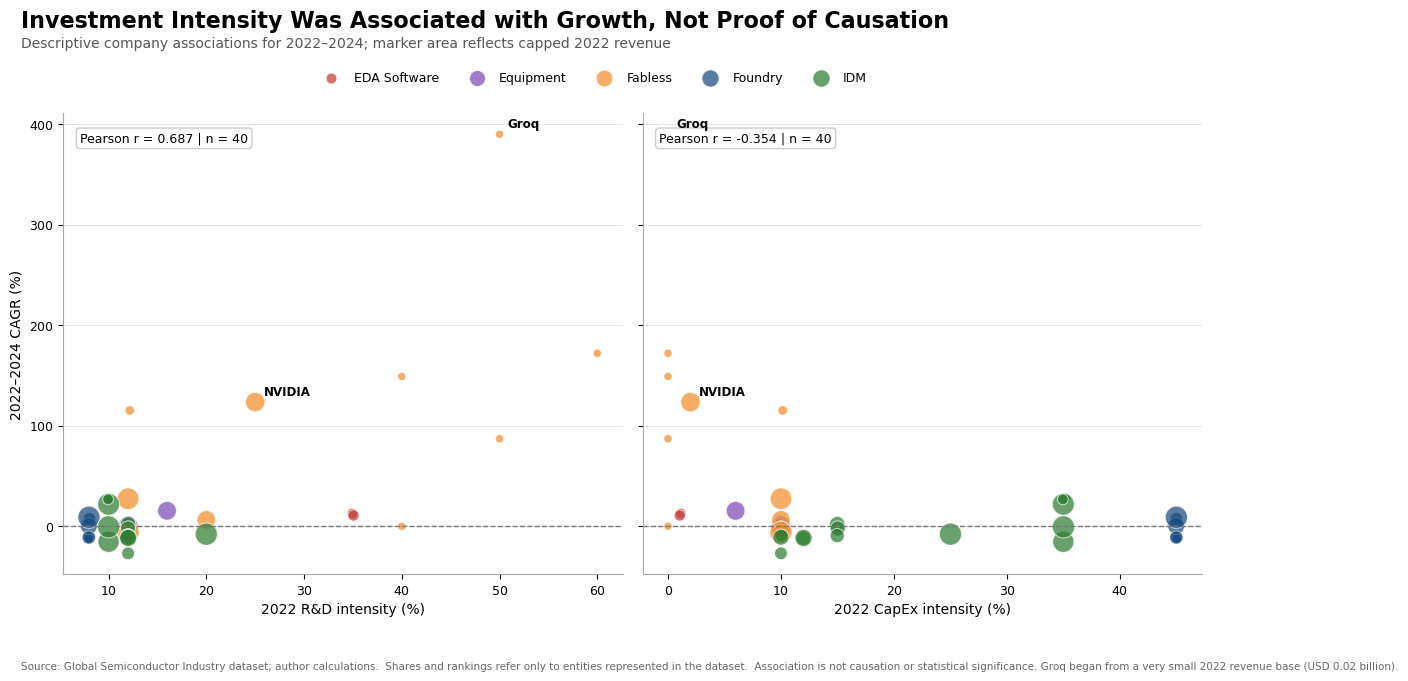

In [9]:
revenue_pair = df_main.loc[df_main.year.isin([2022, 2024])].pivot(index="company_name", columns="year", values="revenue_usd_bn").dropna().rename(columns={2022: "revenue_2022", 2024: "revenue_2024"})
growth = revenue_pair.loc[revenue_pair.revenue_2022.gt(0) & revenue_pair.revenue_2024.gt(0)].copy()
growth["cagr_pct"] = growth.revenue_2024.div(growth.revenue_2022).pow(0.5).sub(1).mul(100)
metrics_2022 = df_main.loc[df_main.year.eq(2022), ["company_name", "value_chain_group", "rd_intensity_pct", "capex_intensity_pct"]].set_index("company_name")
growth = growth.join(metrics_2022).reset_index()
size_ceiling = growth.revenue_2022.quantile(0.90)
growth["marker_area"] = growth.revenue_2022.clip(upper=size_ceiling).div(size_ceiling).mul(220).add(35)
fig, axes = plt.subplots(1, 2, figsize=(13, 6.8), sharey=True)
add_chart_title(fig, "Investment Intensity Was Associated with Growth, Not Proof of Causation", "Descriptive company associations for 2022–2024; marker area reflects capped 2022 revenue")
scatter_specs = [("rd_intensity_pct", "2022 R&D intensity (%)", axes[0]), ("capex_intensity_pct", "2022 CapEx intensity (%)", axes[1])]
for x_column, x_label, ax in scatter_specs:
    valid = growth[[x_column, "cagr_pct"]].notna().all(axis=1)
    plotted = growth.loc[valid]
    for value_chain_group, group in plotted.groupby("value_chain_group"):
        ax.scatter(group[x_column], group.cagr_pct, s=group.marker_area, color=GROUP_COLORS[value_chain_group], alpha=0.72, edgecolor="white", linewidth=0.7, label=value_chain_group)
    correlation = plotted[x_column].corr(plotted.cagr_pct)
    ax.text(0.03, 0.96, f"Pearson r = {correlation:.3f} | n = {len(plotted)}", transform=ax.transAxes, va="top", fontsize=9, bbox={"facecolor": "white", "edgecolor": "#CCCCCC", "boxstyle": "round,pad=0.3"})
    ax.axhline(0, color="#777777", linewidth=1, linestyle="--")
    for company in ["NVIDIA", "Groq"]:
        row = plotted.loc[plotted.company_name.eq(company)]
        if not row.empty:
            record = row.iloc[0]
            ax.annotate(company, (record[x_column], record.cagr_pct), xytext=(6, 5), textcoords="offset points", fontsize=8.5, fontweight="bold")
    format_axis(ax, xlabel=x_label, ylabel="2022–2024 CAGR (%)" if ax is axes[0] else None)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.91), ncol=5, frameon=False)
path_6 = save_figure(fig, "06_investment_intensity_vs_growth.png", 2024, "Association is not causation or statistical significance. Groq began from a very small 2022 revenue base (USD 0.02 billion).")
plt.show()

## Figure 7 — Revenue scale and operating margin

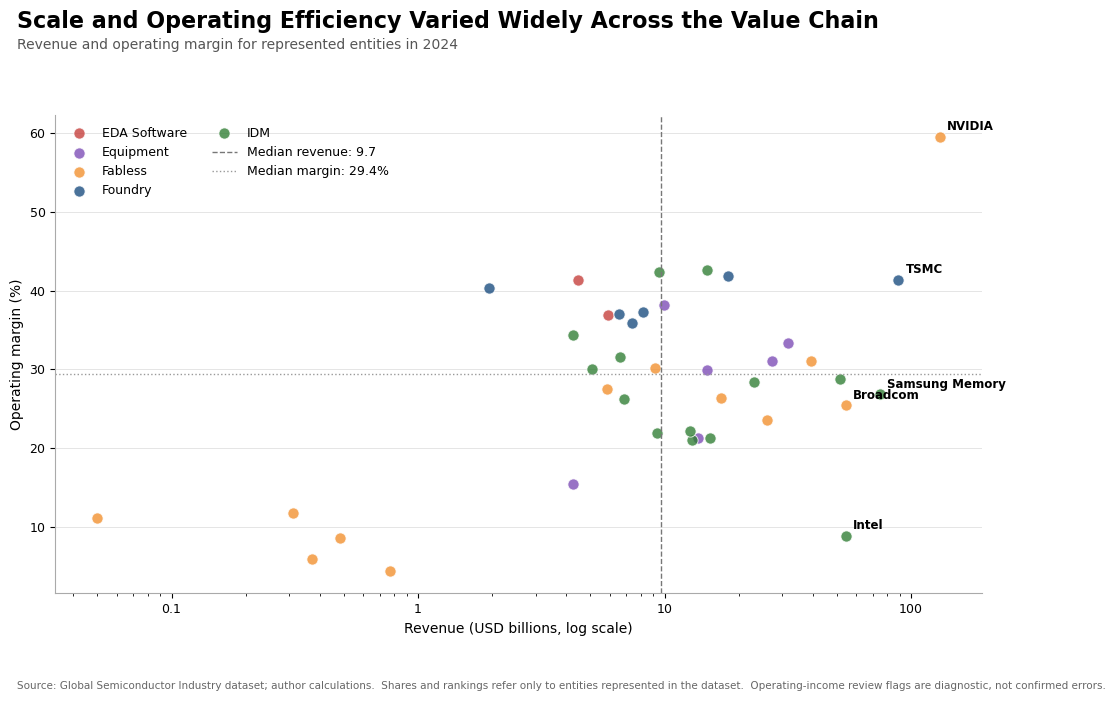

In [10]:
scatter_2024 = df_main.loc[df_main.year.eq(2024) & df_main.revenue_usd_bn.gt(0)].copy()
median_revenue = scatter_2024.revenue_usd_bn.median()
median_margin = scatter_2024.operating_margin_pct.median()
largest_five = scatter_2024.nlargest(5, "revenue_usd_bn")
fig, ax = plt.subplots(figsize=(11, 7))
add_chart_title(fig, "Scale and Operating Efficiency Varied Widely Across the Value Chain", "Revenue and operating margin for represented entities in 2024")
for value_chain_group, group in scatter_2024.groupby("value_chain_group"):
    ax.scatter(group.revenue_usd_bn, group.operating_margin_pct, color=GROUP_COLORS[value_chain_group], s=65, alpha=0.78, edgecolor="white", linewidth=0.7, label=value_chain_group)
ax.axvline(median_revenue, color="#777777", linewidth=1, linestyle="--", label=f"Median revenue: {median_revenue:.1f}")
ax.axhline(median_margin, color="#999999", linewidth=1, linestyle=":", label=f"Median margin: {median_margin:.1f}%")
for _, row in largest_five.iterrows():
    ax.annotate(row.company_name, (row.revenue_usd_bn, row.operating_margin_pct), xytext=(5, 5), textcoords="offset points", fontsize=8.5, fontweight="bold")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:g}"))
ax.legend(frameon=False, ncol=2, loc="best")
format_axis(ax, xlabel="Revenue (USD billions, log scale)", ylabel="Operating margin (%)")
path_7 = save_figure(fig, "07_revenue_vs_margin_2024.png", 2024, "Operating-income review flags are diagnostic, not confirmed errors.")
plt.show()

## Figure Validation

In [11]:
csv_hashes_after = {str(path.relative_to(project_root)): file_sha256(path) for path in csv_paths}
assert csv_hashes_after == csv_hashes_before, "Figure validation failed: at least one raw or processed CSV changed."
figure_validation = pd.DataFrame(figure_records)
figure_validation["file_exists"] = figure_validation.figure_filename.map(lambda name: (figures_dir / name).is_file())
figure_validation["file_size_greater_than_zero"] = figure_validation.figure_filename.map(lambda name: (figures_dir / name).stat().st_size > 0 if (figures_dir / name).is_file() else False)
figure_validation["validation_result"] = figure_validation[["file_exists", "file_size_greater_than_zero", "source_note_included", "limitation_note_included"]].all(axis=1) & (figure_validation.maximum_year_used.le(2024) | (figure_validation.figure_filename.eq("02_value_chain_pre_vs_ai.png") & figure_validation.maximum_year_used.eq(2026)))
figure_validation = figure_validation[["figure_filename", "file_exists", "file_size_greater_than_zero", "maximum_year_used", "source_note_included", "limitation_note_included", "validation_result"]]
assert len(figure_validation) == 7, "Figure validation failed: expected seven figure records."
assert figure_validation.file_exists.all(), "Figure validation failed: at least one PNG does not exist."
assert figure_validation.file_size_greater_than_zero.all(), "Figure validation failed: at least one PNG is empty."
assert (figure_validation.maximum_year_used.le(2024) | (figure_validation.figure_filename.eq("02_value_chain_pre_vs_ai.png") & figure_validation.maximum_year_used.eq(2026))).all(), "Figure validation failed: unexpected year coverage outside the declared figure windows."
assert not df_main.select_dtypes(include="number").isin([float("inf"), float("-inf")]).any().any(), "Figure validation failed: infinite values were available for plotting."
assert figure_validation.validation_result.all(), "Figure validation failed: one or more figure checks failed."
display(figure_validation)
display(pd.Series({"all_seven_png_files_exist": figure_validation.file_exists.all(), "all_seven_files_nonempty": figure_validation.file_size_greater_than_zero.all(), "all_figures_use_declared_year_windows": (figure_validation.maximum_year_used.le(2024) | (figure_validation.figure_filename.eq("02_value_chain_pre_vs_ai.png") & figure_validation.maximum_year_used.eq(2026))).all(), "csv_hashes_unchanged": csv_hashes_after == csv_hashes_before, "no_infinite_values_plotted": not df_main.select_dtypes(include="number").isin([float("inf"), float("-inf")]).any().any()}, name="passed").to_frame())

,figure_filename,file_exists,file_size_greater_than_zero,maximum_year_used,source_note_included,limitation_note_included,validation_result
0,01_industry_revenue_trend.png,True,True,2024,True,True,True
1,02_value_chain_pre_vs_ai.png,True,True,2026,True,True,True
2,03_top10_revenue_2024.png,True,True,2024,True,True,True
3,04_revenue_change_2022_2024.png,True,True,2024,True,True,True
4,05_revenue_concentration.png,True,True,2024,True,True,True
5,06_investment_intensity_vs_growth.png,True,True,2024,True,True,True
6,07_revenue_vs_margin_2024.png,True,True,2024,True,True,True


,passed
all_seven_png_files_exist,True
all_seven_files_nonempty,True
all_figures_use_declared_year_windows,True
csv_hashes_unchanged,True
no_infinite_values_plotted,True


## Visualization Conclusions

Figure 1 communicates the 2024 revenue rebound alongside entity coverage. 

Figure 2 compares average annual value-chain revenue across Smart automobile expansion, Transition Year, and AI expansion, including flagged 2025–2026 observations. 

Figures 3 and 4 show 2024 scale and absolute 2022–2024 revenue gains, with NVIDIA leading both. 

Figure 5 provides strong direct evidence of dataset concentration through the largest, top-3, and top-5 revenue shares. Figure 7 provides strong cross-sectional evidence that revenue scale and operating margins vary across value-chain groups. Figure 6 shows descriptive investment-growth associations only; it does not establish causation or statistical significance. Groq is not the main growth headline because its high CAGR begins from a very small 2022 revenue base, while the main headline uses NVIDIA’s much larger absolute revenue increase.